In [1]:
import numpy as np, scipy as sp
import lightkurve as lk, idlsave
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
mcmcss =idlsave.read("hd74925.2mist-spciso.sav", verbose=False)
rstars = mcmcss.rstar
lstars = mcmcss.lstar
ages = mcmcss.age
logmstars = mcmcss.logmstar
teffs = mcmcss.teff
fehs = mcmcss.feh

In [3]:
#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

In [ ]:
plt.close('all')
y,x,_=plt.hist(ages[0:,], 1000, alpha=.3, label='Age PDF')
bin_center = x[1:] - 0.5*np.diff(x)
#(mu1, sigma1, A1, mu2, sigma2, A2)
expected = (3.75, 0.25, 575, 6.3, 0.4, 575)
params, cov = curve_fit(bimodal, bin_center, y, expected)
x_fit = np.linspace(bin_center.min(), bin_center.max(), 1000)
sigma=np.sqrt(np.diag(cov))
params_1g, cov_1g = curve_fit(gauss, bin_center,
                             y,expected[:3])
sigma_1g=np.sqrt(np.diag(cov_1g))
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
#...and individual Gauss curves
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')
plt.plot(x_fit, gauss(x_fit, *params_1g[:3]),
         color='orange', lw=1, ls="-.", label='1-Gaussian fit')
#and the original data points if no histogram has been created before
#plt.scatter(x, y, marker="X", color="black", label="original data")
plt.ylabel("PDF (counts)")
plt.xlabel("Age")
plt.legend()
print("Age 2-Gaussian fit results:")
print("mu1:", params[0], "+/-", sigma[0])
print("sigma1:", params[1], "+/-", sigma[1])
print("A1 (f = A*exp((x-mu^2)/sigma^2)):",
      params[2], "+/-", sigma[2])
print("mu2:", params[3], "+/-", sigma[3])
print("sigma2:", params[4], "+/-", sigma[4])
print("A2 (f = A*exp((x-mu^2)/sigma^2)):",
      params[5], "+/-", sigma[5])
print("1 Gaussian fit:")
print("mu:", params_1g[0], "+/-", sigma_1g[0])
print("sigma:", params_1g[1], "+/-", sigma_1g[1])
print("A:", params_1g[2], "+/-", sigma_1g[2])

R2 2-Gaussian fit results:
mu1: 0.17964972962230247 +/- 2.1756248292298037e-05
sigma1: 0.002627111621910685 +/- 2.3690681416643792e-05
A1 (f = A*exp((x-mu^2)/sigma^2)): 708.8750616516587 +/- 4.416714552003878
mu2: 0.18785358233634422 +/- 3.29073817060634e-05
sigma2: 0.0021252989255173896 +/- 3.406453998978051e-05
A2 (f = A*exp((x-mu^2)/sigma^2)): 427.05255130036244 +/- 4.820684675091161
1 Gaussian fit:
mu: 0.18151711237255494 +/- 9.143403242871868e-05
sigma: 0.005401300949665615 +/- 9.171596102347174e-05
A: 542.186523988132 +/- 7.952380033938978


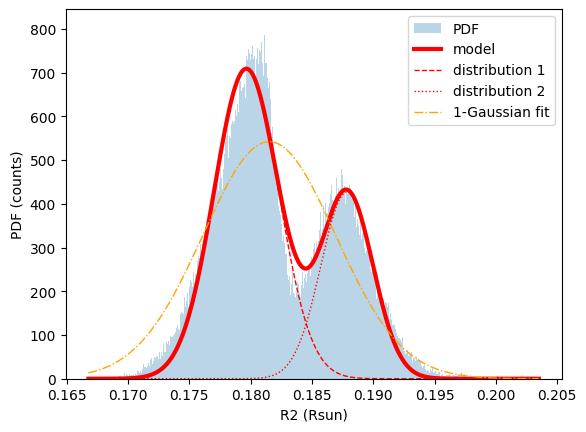

In [20]:
plt.close('all')
y,x,_=plt.hist(rstars[1,:], 1000, alpha=.3, label='PDF')
bin_center = x[1:] - 0.5*np.diff(x)
#(mu1, sigma1, A1, mu2, sigma2, A2)
expected = (0.18, 0.0025, 750, 0.1875, 0.0025, 410)
params, cov = curve_fit(bimodal, bin_center, y, expected)
x_fit = np.linspace(bin_center.min(), bin_center.max(), 1000)
sigma=np.sqrt(np.diag(cov))
params_1g, cov_1g = curve_fit(gauss, bin_center,
                             y,expected[:3])
sigma_1g=np.sqrt(np.diag(cov_1g))

plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
#...and individual Gauss curves
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')
plt.plot(x_fit, gauss(x_fit, *params_1g[:3]),
         color='orange', lw=1, ls="-.", label='1-Gaussian fit')
#and the original data points if no histogram has been created before
#plt.scatter(x, y, marker="X", color="black", label="original data")
plt.ylabel("PDF (counts)")
plt.xlabel("R2 (Rsun)")
plt.legend()
print("R2 2-Gaussian fit results:")
print("mu1:", params[0], "+/-", sigma[0])
print("sigma1:", params[1], "+/-", sigma[1])
print("A1 (f = A*exp((x-mu^2)/sigma^2)):",
      params[2], "+/-", sigma[2])
print("mu2:", params[3], "+/-", sigma[3])
print("sigma2:", params[4], "+/-", sigma[4])
print("A2 (f = A*exp((x-mu^2)/sigma^2)):",
      params[5], "+/-", sigma[5])
print("1 Gaussian fit:")
print("mu:", params_1g[0], "+/-", sigma_1g[0])
print("sigma:", params_1g[1], "+/-", sigma_1g[1])
print("A:", params_1g[2], "+/-", sigma_1g[2])


M2 2-Gaussian fit results:
mu1: 0.14492056741517179 +/- 3.48493831530248e-05
sigma1: 0.004148540770804465 +/- 3.781347046876127e-05
A1 (f = A*exp((x-mu^2)/sigma^2)): 771.6097232174718 +/- 4.945672511056107
mu2: 0.15839409879845753 +/- 5.5818908648740336e-05
sigma2: 0.0035373684306308248 +/- 5.8412820466872064e-05
A2 (f = A*exp((x-mu^2)/sigma^2)): 449.4889234410242 +/- 5.281851586678634
1 Gaussian fit:
mu: 0.1479081803016019 +/- 0.00015627076286440356
sigma: 0.00876329194509105 +/- 0.00015729994721711197
A: 576.576173206634 +/- 8.911035347192486


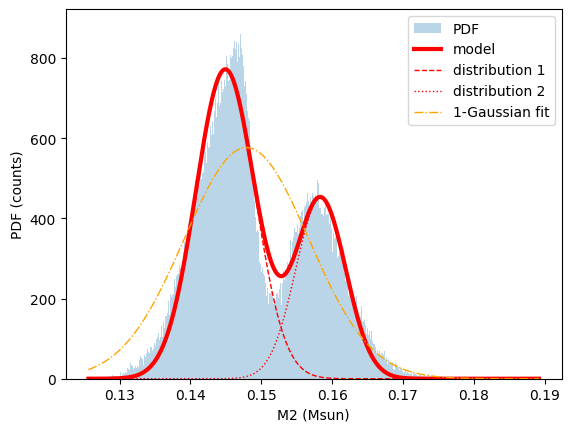

In [21]:
plt.close('all')
y,x,_=plt.hist(10**logmstars[1,:], 1000, alpha=.3, label='PDF')
bin_center = x[1:] - 0.5*np.diff(x)
#(mu1, sigma1, A1, mu2, sigma2, A2)
expected = (0.145, 0.005, 750, 0.16, 0.005, 410)
params, cov = curve_fit(bimodal, bin_center,
                        y, expected)
params_1g, cov_1g = curve_fit(gauss, bin_center,
                             y,expected[:3])
x_fit = np.linspace(bin_center.min(), bin_center.max(), 1000)
sigma=np.sqrt(np.diag(cov))
sigma_1g=np.sqrt(np.diag(cov_1g))
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
#...and individual Gauss curves
plt.plot(x_fit, gauss(x_fit, *params[:3]),
         color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]),
         color='red', lw=1, ls=":", label='distribution 2')
plt.plot(x_fit, gauss(x_fit, *params_1g[:3]),
         color='orange', lw=1, ls="-.", label='1-Gaussian fit')
#and the original data points if no histogram has been created before
#plt.scatter(x, y, marker="X", color="black", label="original data")
plt.ylabel("PDF (counts)")
plt.xlabel("M2 (Msun)")
plt.legend()
print("M2 2-Gaussian fit results:")
print("mu1:", params[0], "+/-", sigma[0])
print("sigma1:", params[1], "+/-", sigma[1])
print("A1 (f = A*exp((x-mu^2)/sigma^2)):",
      params[2], "+/-", sigma[2])
print("mu2:", params[3], "+/-", sigma[3])
print("sigma2:", params[4], "+/-", sigma[4])
print("A2 (f = A*exp((x-mu^2)/sigma^2)):",
      params[5], "+/-", sigma[5])
print("1 Gaussian fit:")
print("mu:", params_1g[0], "+/-", sigma_1g[0])
print("sigma:", params_1g[1], "+/-", sigma_1g[1])
print("A:", params_1g[2], "+/-", sigma_1g[2])
